<a href="https://colab.research.google.com/github/Lande21/Datascience_projects/blob/main/RU_Assignment4_Transactions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importing the libraries necessary
#Author: Rolande U
#Date: 04/21/2025
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Setting a clear plotting area

#sns.set(style="whitegrid", palette="pastel")

# READ ME FIRST

Tasks required to do to run my models/colab

1. Download the data set on my github/ from CIS 518/418 D2L content
2. Upload the file to your google drive
3. Mount the drive up on opeing the colab file
4. Find and copy the dataset file
5. Read the file / paste the path below

**>>>Change file path BEFORE RUN**

In [3]:
#Download the csv file and upload it on the drive, mount and use the corresponding path to our dataset file
# add file path that corresponds to where your file is located
df = pd.read_csv('/content/drive/MyDrive/CIS518_Foundations_ofDS/Online_transaction_data.csv')

In [4]:
#Checking our dataset
df.head(10)

,Transaction Time,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,...,PCA21,PCA22,PCA23,PCA24,PCA25,PCA26,PCA27,PCA28,Amount,Type_of_Transaction
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,Normal
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,Normal
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,Normal
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,Normal
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,Normal
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,Normal
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,Normal
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,Normal
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,Normal
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,Normal


In [5]:
# fields and #records
df.shape

(284807, 31)

In [6]:
#looking into the stats of our dataset
df.describe()

,Transaction Time,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,...,PCA20,PCA21,PCA22,PCA23,PCA24,PCA25,PCA26,PCA27,PCA28,Amount
count,284807.000000,2.848070e+05,2.848070e+05,284805.000000,284806.000000,2.848070e+05,284805.000000,2.848070e+05,284804.000000,284797.000000,...,284805.000000,2.848050e+05,2.848060e+05,284806.000000,2.848060e+05,2.848070e+05,2.848070e+05,2.848060e+05,2.848060e+05,284807.000000
mean,94813.859575,1.759061e-12,-8.251130e-13,-0.000012,-0.000001,1.649999e-13,-0.000009,-3.054600e-13,0.000006,0.000002,...,-0.000003,4.184317e-07,-2.594777e-07,0.000001,-3.848964e-07,-6.987102e-13,-5.617874e-13,3.156142e-07,-1.559143e-07,88.349619
std,47488.145955,1.958696e+00,1.651309e+00,1.516254,1.415871,1.380247e+00,1.332261,1.237094e+00,1.194356,1.098628,...,0.770927,7.345266e-01,7.257028e-01,0.624461,6.056481e-01,5.212781e-01,4.822270e-01,4.036332e-01,3.300838e-01,250.120109
min,0.000000,-5.640751e+01,-7.271573e+01,-48.325589,-5.683171,-1.137433e+02,-26.160506,-4.355724e+01,-73.216718,-13.434066,...,-54.497720,-3.483038e+01,-1.093314e+01,-44.807735,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-0.890372,-0.848642,-6.915971e-01,-0.768296,-5.540759e-01,-0.208629,-0.643096,...,-0.211722,-2.283999e-01,-5.423514e-01,-0.161846,-3.545895e-01,-3.171451e-01,-3.269839e-01,-7.083937e-02,-5.295995e-02,5.600000
50%,84692.000000,1.810880e-02,6.548556e-02,0.179845,-0.019848,-5.433583e-02,-0.274187,4.010308e-02,0.022359,-0.051436,...,-0.062481,-2.944510e-02,6.781490e-03,-0.011193,4.097377e-02,1.659350e-02,-5.213911e-02,1.342244e-03,1.124381e-02,22.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027167,0.743348,6.119264e-01,0.398560,5.704361e-01,0.327347,0.597140,...,0.133031,1.863843e-01,5.285544e-01,0.147642,4.395270e-01,3.507156e-01,2.409522e-01,9.104579e-02,7.828043e-02,77.165000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558,16.875344,3.480167e+01,73.301626,1.205895e+02,20.007208,15.594995,...,39.420904,2.720284e+01,1.050309e+01,22.528412,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Transaction Time     284807 non-null  float64
 1   PCA1                 284807 non-null  float64
 2   PCA2                 284807 non-null  float64
 3   PCA3                 284805 non-null  float64
 4   PCA4                 284806 non-null  float64
 5   PCA5                 284807 non-null  float64
 6   PCA6                 284805 non-null  float64
 7   PCA7                 284807 non-null  float64
 8   PCA8                 284804 non-null  float64
 9   PCA9                 284797 non-null  float64
 10  PCA10                284805 non-null  float64
 11  PCA11                284807 non-null  float64
 12  PCA12                284803 non-null  float64
 13  PCA13                284804 non-null  float64
 14  PCA14                284806 non-null  float64
 15  PCA15            

In [8]:
# Handling the missing values

total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PCA19,12,0.000042
PCA9,10,0.000035
PCA12,4,0.000014
PCA17,4,0.000014
PCA15,3,0.000011
PCA8,3,0.000011
PCA13,3,0.000011
PCA18,2,0.000007
PCA3,2,0.000007
PCA20,2,0.000007


In [9]:
# Handling missing values
# Getting columns with missing values
missing_data = df.isnull().sum()
missing_cols = missing_data[missing_data > 0].index

# And imputing with mean for numeric columns since the data is already standardized
for col in missing_cols:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].mean())
missing_dat_afterimputation = df.isnull().sum()
#print(missing_dat_afterimputation[missing_dat_afterimputation > 0])
#df.head(10)
df_update =  df.copy()
df_update.head(10)


,Transaction Time,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,...,PCA21,PCA22,PCA23,PCA24,PCA25,PCA26,PCA27,PCA28,Amount,Type_of_Transaction
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,Normal
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,Normal
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,Normal
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,Normal
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,Normal
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,Normal
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,Normal
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,Normal
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,Normal
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,Normal


In [10]:
# finding different types of transaction from our data
print(df_update['Type_of_Transaction'].value_counts())
print(df_update['Type_of_Transaction'].value_counts(normalize=True))  # % of each class


Type_of_Transaction
Normal     284315
Unusual       492
Name: count, dtype: int64
Type_of_Transaction
Normal     0.998273
Unusual    0.001727
Name: proportion, dtype: float64


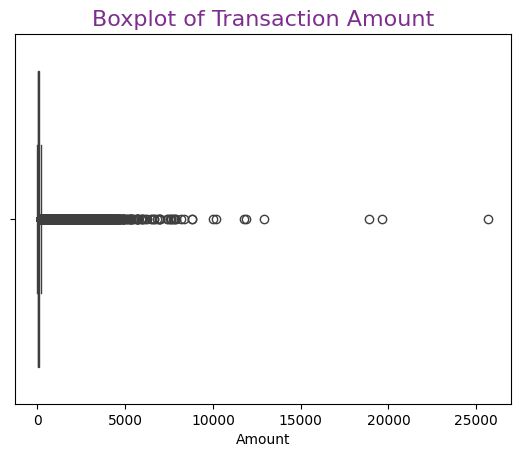

In [11]:
# Visualize Amount
sns.boxplot(x=df_update['Amount'])
plt.title("Boxplot of Transaction Amount", fontsize=16, color="#7E2F8E")
plt.show()

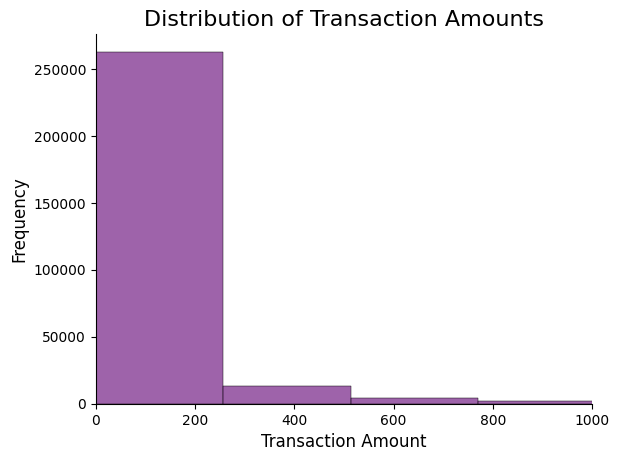

In [12]:
# finding the frequency of the transaction
sns.histplot(df_update['Amount'], bins=100, color="#7E2F8E")
plt.title("Distribution of Transaction Amounts", fontsize=16)
plt.xlabel("Transaction Amount", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xlim(0, 1000)
sns.despine() # Remove top and right spines for a cleaner look
plt.show()

In [13]:
# Basic statistics
print("Basic Statistics for Amount:")
print(df_update['Amount'].describe())

# Check for outliers in Amount
Q1 = df_update['Amount'].quantile(0.25)
Q3 = df_update['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nAmount Outliers:")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
print(f"Number of outliers: {len(df_update[(df_update['Amount'] < lower_bound) | (df_update['Amount'] > upper_bound)])}")


Basic Statistics for Amount:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Amount Outliers:
Lower bound: -101.7475, Upper bound: 184.5125
Number of outliers: 31904


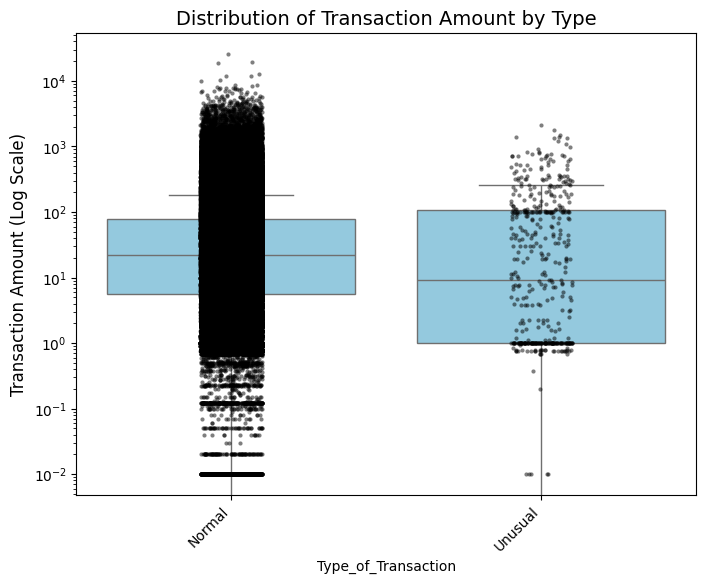

In [14]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Type_of_Transaction', y='Amount', data=df_update, color='skyblue', showfliers=False) # showfliers=False to hide outliers initially
sns.stripplot(x='Type_of_Transaction', y='Amount', data=df_update, color='black', alpha=0.5, size=3) # Adding data points
plt.title('Distribution of Transaction Amount by Type', fontsize=14)
plt.ylabel('Transaction Amount (Log Scale)', fontsize=12)
plt.yscale('log')  # Log scale for better visualization of skewed data
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels if needed
plt.show()

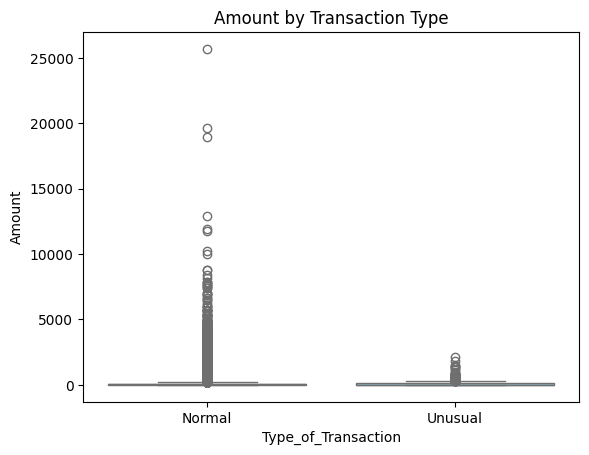

In [15]:
#Visualizing the outliers
sns.boxplot(x='Type_of_Transaction', y='Amount', data=df_update, color='skyblue')
plt.title('Amount by Transaction Type')
plt.show()



                      Count    Percent
Type_of_Transaction                   
Normal               284315  99.827251
Unusual                 492   0.172749


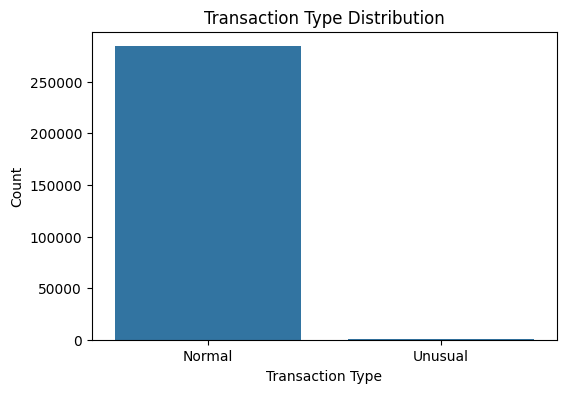

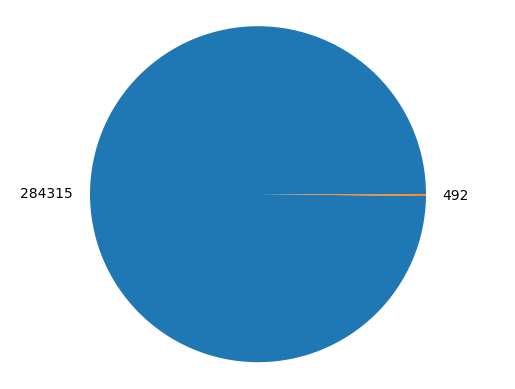

In [16]:
# The EDA reports
# 1
# Count and % of each transaction type
class_counts = df_update['Type_of_Transaction'].value_counts()
class_percent = df_update['Type_of_Transaction'].value_counts(normalize=True) * 100

print(pd.concat([class_counts, class_percent], axis=1, keys=['Count', 'Percent']))


# Barplot
plt.figure(figsize=(6,4))
sns.countplot(data=df_update, x='Type_of_Transaction')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.title('Transaction Type Distribution')
plt.show()
#3
# Pie chart for two types of transactions
plt.pie(class_percent, labels=class_counts)
plt.axis('equal')
plt.show()

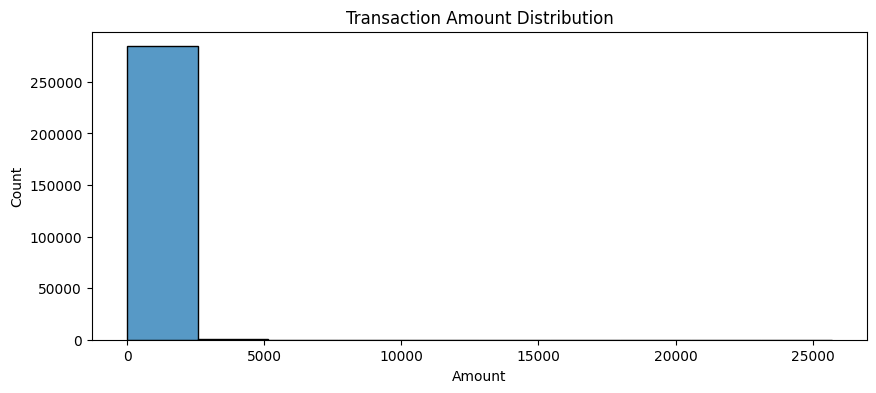

In [17]:
#Transaction amount analysis report
# 4
# Distribution
plt.figure(figsize=(10,4))
sns.histplot(df_update['Amount'], bins=10)
plt.title("Transaction Amount Distribution")
plt.show()




Text(0.5, 1.0, 'PCA1 vs PCA2 by Transaction Type')

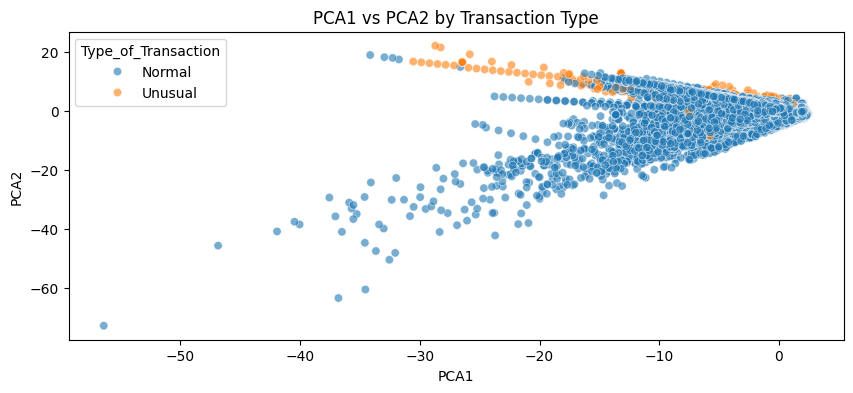

In [18]:
# 3
# EDA
plt.figure(figsize=(10,4))
sns.scatterplot(x='PCA1', y='PCA2', hue='Type_of_Transaction', data=df_update, alpha=0.6)
plt.title('PCA1 vs PCA2 by Transaction Type')

Text(0.5, 1.0, 'PCA23 vs PCA25 by Transaction Type')

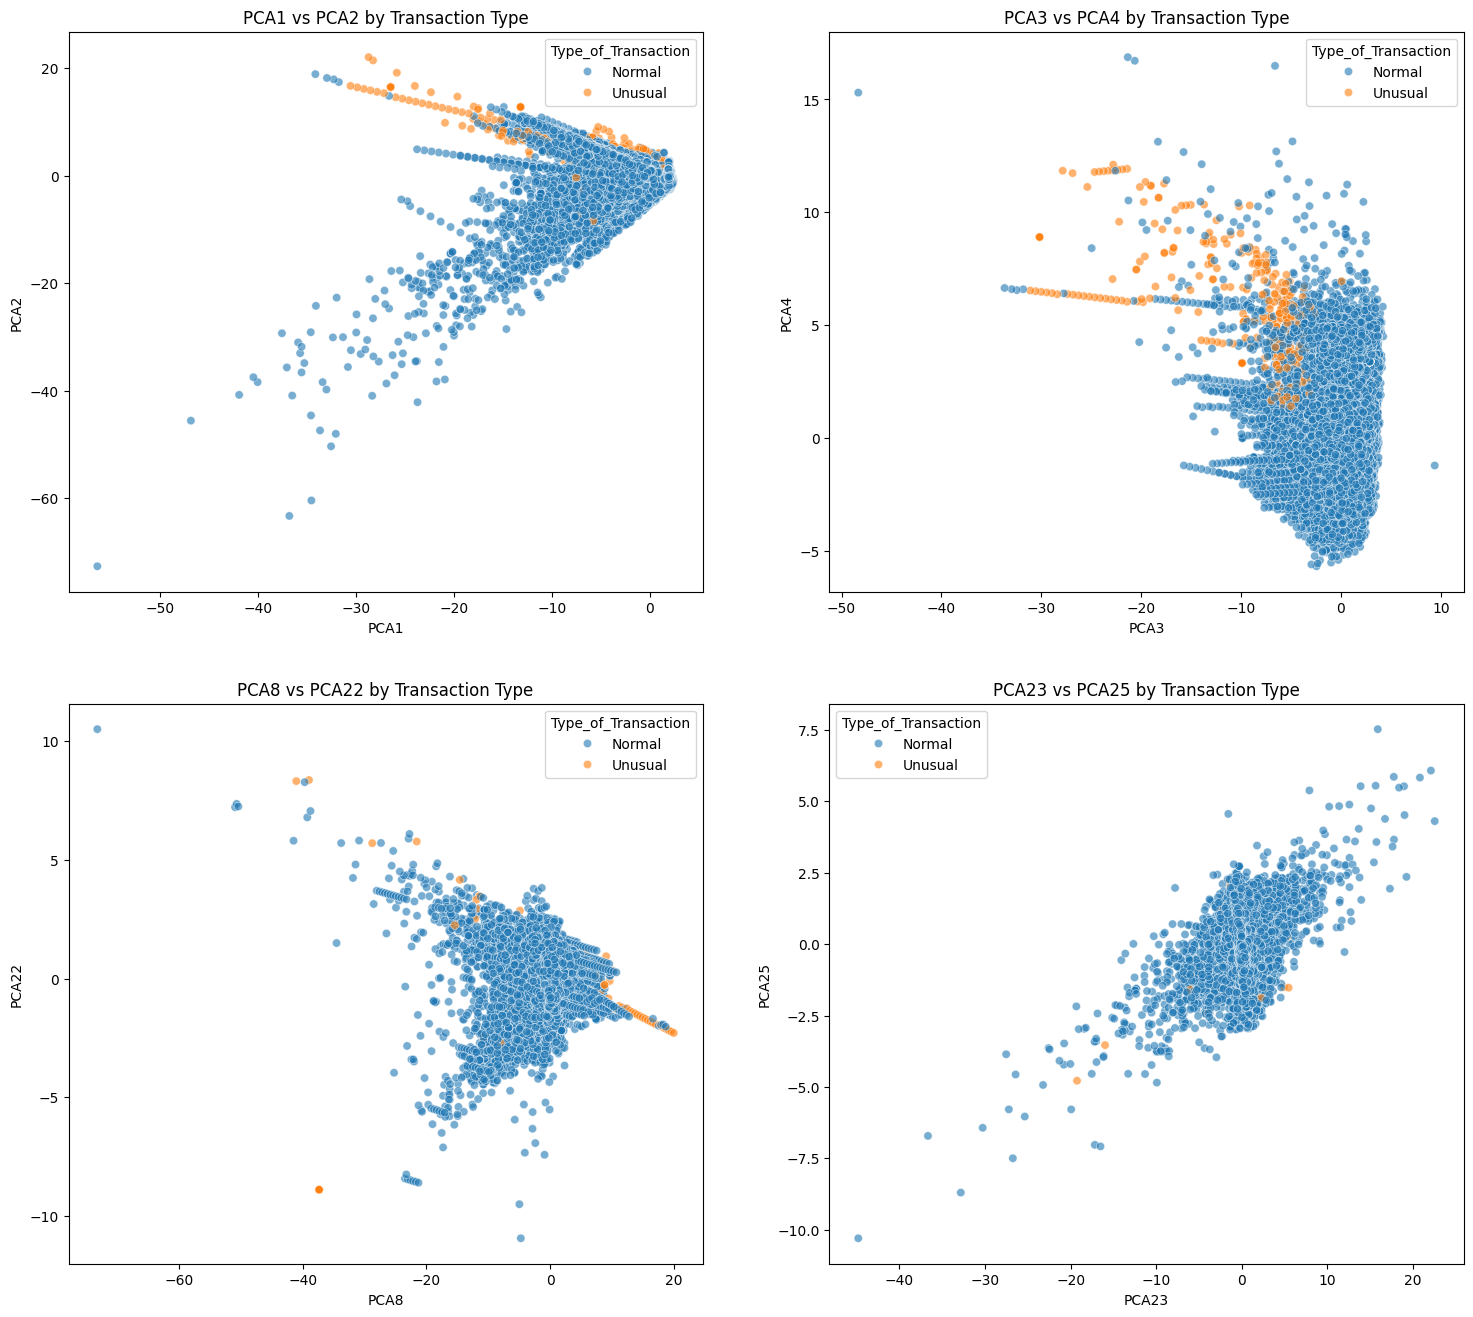

In [19]:
# Additional visualizations to find more significant PCAs
plt.figure(figsize=(18, 16))

# 5. PCA1 vs PCA2 Scatter Plot
plt.subplot(2, 2, 1)
sns.scatterplot(x='PCA1', y='PCA2', hue='Type_of_Transaction', data=df_update, alpha=0.6)
plt.title('PCA1 vs PCA2 by Transaction Type')

# 6. PCA3 vs PCA4 Scatter Plot
plt.subplot(2, 2, 2)
sns.scatterplot(x='PCA3', y='PCA4', hue='Type_of_Transaction', data=df_update, alpha=0.6)
plt.title('PCA3 vs PCA4 by Transaction Type')
# 7. PCA8 vs PCA22 Scatter Plot
plt.subplot(2, 2, 3)
sns.scatterplot(x='PCA8', y='PCA22', hue='Type_of_Transaction', data=df_update, alpha=0.6)
plt.title('PCA8 vs PCA22 by Transaction Type')

# 8. PCA8 vs PCA22 Scatter Plot
plt.subplot(2, 2, 4)
sns.scatterplot(x='PCA23', y='PCA25', hue='Type_of_Transaction', data=df_update, alpha=0.6)
plt.title('PCA23 vs PCA25 by Transaction Type')

In [ ]:
# TASK 3
#Using t-test for Two Groups (Target: Normal vs. Unusual)
#A T-test compares the means of two groups (normal vs Unusual) and
# tests if the difference is statistically significant.
'''A feature with a P-value < 0.05 indicates a statistically
significant difference in means between the normal and unusual transactions.
These features are likely important for distinguishing the two transaction types.'''

from scipy.stats import ttest_ind

# Split data into normal and abnormal
normal_transactions = df_update[df_update['Type_of_Transaction'] == 'Normal']
unusual_transactions = df_update[df_update['Type_of_Transaction'] == 'Unusual']

# T-test for numeric features (Amount, PCA components)
numeric_features = ['Amount'] + [col for col in df_update.columns if col.startswith('PCA')]

# Run T-test
t_test_results = {}
for feature in numeric_features:
    normal_vals = normal_transactions[feature]
    abnormal_vals = unusual_transactions[feature]

    t_stat, p_value = ttest_ind(normal_vals, abnormal_vals, equal_var=False)  # Welch's T-test (unequal variance)
    t_test_results[feature] = p_value

# Displaying results
t_test_results_df = pd.DataFrame(list(t_test_results.items()), columns=['Feature', 'P-value'])
t_test_results_df['Significant'] = t_test_results_df['P-value'] < 0.05  # Threshold for significance
print(t_test_results_df)


   Feature        P-value  Significant
0   Amount   3.560519e-03         True
1     PCA1   5.491643e-45         True
2     PCA2   1.288580e-59         True
3     PCA3   4.788008e-75         True
4     PCA4  4.586888e-136         True
5     PCA5   1.497028e-33         True
6     PCA6   5.887139e-50         True
7     PCA7   4.292231e-52         True
8     PCA8   6.276080e-02        False
9     PCA9   1.193241e-79         True
10   PCA10   3.383042e-93         True
11   PCA11  4.577212e-120         True
12   PCA12  1.480548e-112         True
13   PCA13   2.842564e-02         True
14   PCA14  1.040079e-140         True
15   PCA15   4.992703e-02         True
16   PCA16   7.905084e-84         True
17   PCA17   1.558076e-71         True
18   PCA18   2.640156e-52         True
19   PCA19   6.714337e-21         True
20   PCA20   1.687141e-09         True
21   PCA21   4.882179e-05         True
22   PCA22   8.346762e-01        False
23   PCA23   5.710275e-01        False
24   PCA24   7.565782e-06

In [ ]:
# TASK 4

# Creating binary target value for easier analysis
data = df_update.copy()
data['Type_of_Transaction'] = data['Type_of_Transaction'].apply(lambda x: 1 if x == 'Normal' else 0)

#data['Type_of_Transaction'].replace({'Normal':1, 'Unusual':0}, inplace=True)
data.head(10)

,Transaction Time,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,...,PCA21,PCA22,PCA23,PCA24,PCA25,PCA26,PCA27,PCA28,Amount,Type_of_Transaction
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,1
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,1
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,1
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,1
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,1
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,1
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,1
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,1
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,1
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,1


# Model Comparison and Testing

**The GOAL:**

Build and train the following machine learning models (80% of the overall data):


*   Decision Tree
*   Logistic Regression
*   Naïve Bayes

# Model Training

**STEP 1: Importing the classes**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


**STEP 2:  Instantiating the estimator**

**Model instantiation and training**


In [ ]:
# 1. Preparing the data
# Features (X): Select the relevant features (PCA components, Amount)
# Target (y): 'Type_of_Transaction' (already binary in 'data' DataFrame)
X = data[['Amount', 'PCA1', 'PCA2', 'PCA3', 'PCA4','PCA5','PCA6','PCA7','PCA9','PCA10','PCA11','PCA12','PCA13','PCA14','PCA15','PCA16','PCA17','PCA18','PCA19','PCA20','PCA21','PCA24','PCA25','PCA26','PCA27','PCA28']]
y = data['Type_of_Transaction']


In [ ]:
# 2. Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
print(X_train.shape)
print(X_test.shape)
#print(y_train.shape)
#print(y_test.shape)

(227845, 26)
(56962, 26)


In [ ]:
# 3. Feature scaling (for Logistic Regression and Naive Bayes)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data preparation completed successfully!")
print(X_train.shape)
print(X_test.shape)

Data preparation completed successfully!
(227845, 26)
(56962, 26)


**STEP 3: Fit the model with data**






In [ ]:
# 4. Initialize and train the models
# a. Decision Tree
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)

# b. Logistic Regression
logistic_regression = LogisticRegression(random_state=42)
logistic_regression.fit(X_train, y_train)

# c. Naive Bayes
naive_bayes = GaussianNB()
naive_bayes.fit(X_train, y_train)

print("Models trained successfully!")

Models trained successfully!


STEP 4:  **Predicting the response for a new observation**

In [ ]:

# Evaluating all models
def evaluate_model(model_name, y_true, y_pred):
    print(f"{model_name} Model Evaluation:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    print("-" * 60)

# Get predictions for each model on the test set
dt_pred = decision_tree.predict(X_test)  # Predictions from Decision Tree
lr_pred = logistic_regression.predict(X_test)  # Predictions from Logistic Regression
nb_pred = naive_bayes.predict(X_test)  # Predictions from Naive Bayes


# Evaluate Decision Tree
evaluate_model("Decision Tree", y_test, dt_pred)
# Evaluate Logistic Regression
evaluate_model("Logistic Regression", y_test, lr_pred)
# Evaluate Naive Bayes
evaluate_model("Naive Bayes", y_test, nb_pred)

Decision Tree Model Evaluation:
Accuracy: 0.9992
Precision: 0.9996
Recall: 0.9996
F1 Score: 0.9996
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.79      0.78        98
           1       1.00      1.00      1.00     56864

    accuracy                           1.00     56962
   macro avg       0.89      0.89      0.89     56962
weighted avg       1.00      1.00      1.00     56962

------------------------------------------------------------
Logistic Regression Model Evaluation:
Accuracy: 0.9991
Precision: 0.9993
Recall: 0.9998
F1 Score: 0.9995
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.57      0.68        98
           1       1.00      1.00      1.00     56864

    accuracy                           1.00     56962
   macro avg       0.92      0.79      0.84     56962
weighted avg       1.00      1.00      1.00     56962

-----------------------------------

In [ ]:
# Check the distribution of the target variable
print("Class Distribution Before Split:")
print(y.value_counts())


Class Distribution Before Split:
Type_of_Transaction
1    284315
0       492
Name: count, dtype: int64


In [ ]:
# Check the distribution of the target variable after split
print("Class Distribution in Training Set:")
print(y_train.value_counts())

print("Class Distribution in Testing Set:")
print(y_test.value_counts())


Class Distribution in Training Set:
Type_of_Transaction
1    227451
0       394
Name: count, dtype: int64
Class Distribution in Testing Set:
Type_of_Transaction
1    56864
0       98
Name: count, dtype: int64


# Hyper parameter tuning for Decision Tree

I chose to use Randomized search cross validation because it is a better approach for our large dataset and we have high number of parameters to tune and it is random, it saves us time to not run through all features.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
import scipy.stats as stats

#dt = DecisionTreeClassifier(random_state=42)

#Making a dictionary of hyperparameter values to search
param_dist_dt = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

random_search_dt = RandomizedSearchCV(
    decision_tree,
    param_distributions=param_dist_dt,
    n_iter=10,             # trying only 10 random combinations
    cv=3,
    scoring='precision',
    random_state=42,
    n_jobs=-1              # using all cpu cores
)

random_search_dt.fit(X_train, y_train)

print("Best Parameters:", random_search_dt.best_params_)
print("Best Score:", random_search_dt.best_score_)


Best Parameters: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'criterion': 'gini'}
Best Score: 0.9996218074920771


# Hyperparameter tuning for Logistic regression

had a minor error before and when i changed to a different solver('lbfgs') worked great.

In [ ]:


# Define the distributions
param_distributions = {
    'penalty': ['l2'],
    'solver': ['lbfgs'],  # Only solvers that support l1 and l2
    'C': stats.uniform(1, 5),
    'max_iter': stats.randint(100, 500)
}

# Set up RandomizedSearchCV

random_search_lr = RandomizedSearchCV(
    estimator=logistic_regression,
    param_distributions=param_distributions,
    n_iter=5,  # Number of random settings to sample
    cv=3,        # Cross-validation folds
    scoring='precision',
    random_state=42,
    n_jobs=-1,   # Use all cores for parallelization
    error_score='raise'  # Immediately show errors
)

# Fit
random_search_lr.fit(X_train, y_train)

# Output results
print("Best Hyperparameters (Logistic Regression):", random_search_lr.best_params_)
print("Best Score (Logistic Regression):", random_search_lr.best_score_)


Best Hyperparameters (Logistic Regression): {'C': np.float64(1.9171739493308189), 'max_iter': 171, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Score (Logistic Regression): 0.9993628254895892


with accuracy i got the score less than using precision for scoring: 0.9993628254895892

**so, i chose to use precision for scoring**

# Hyperparameter tuning for Naive Bayes


*   var_smoothing
*   priors

In [ ]:

# Define the distributions for Naive Bayes hyperparameters
param_distributions = {
    'var_smoothing': stats.uniform(1e-9, 1e-3),  # Smoothing parameter for GaussianNB
    'priors': [None, [0.5, 0.5], [0.3, 0.7]],  # Some possible class priors
}

# Set up RandomizedSearchCV
#naive_bayes = GaussianNB()

random_search_nb = RandomizedSearchCV(
    estimator=naive_bayes,
    param_distributions=param_distributions,
    n_iter=50,  # Number of random settings to sample
    cv=5,        # Cross-validation folds
    scoring='precision',
    random_state=42,
    n_jobs=-1,   # Use all cores for parallelization
    error_score='raise'  # Immediately show errors
)

# Fit
random_search_nb.fit(X_train, y_train)

# Output results
print("Best Hyperparameters (Naive Bayes):", random_search_nb.best_params_)
print("Best Score (Naive Bayes):", random_search_nb.best_score_)


Best Hyperparameters (Naive Bayes): {'priors': [0.5, 0.5], 'var_smoothing': np.float64(0.0007219997722668248)}
Best Score (Naive Bayes): 0.9997526274339211


0.9812416335666792

# Making the model with better performance comparative to the three models:

In [ ]:
# 1. Get the best parameters for LR
best_params_lr = random_search_lr.best_params_

# 2. Build the final Logistic Regression model with best parameters
from sklearn.linear_model import LogisticRegression

final_lr_model = LogisticRegression(**best_params_lr)
final_lr_model.fit(X_train, y_train)

# 3. Predict on the test set
y_pred = final_lr_model.predict(X_test)
y_proba = final_lr_model.predict_proba(X_test)[:,1]  # for ROC AUC

# 4. Evaluate the model
from sklearn.metrics import classification_report, roc_auc_score

print("Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred))

print("ROC AUC Score (Logistic Regression):", roc_auc_score(y_test, y_proba))


Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.85      0.57      0.68        98
           1       1.00      1.00      1.00     56864

    accuracy                           1.00     56962
   macro avg       0.92      0.79      0.84     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score (Logistic Regression): 0.9711877892687747


In [ ]:

# Get the best parameters (if any; usually Naive Bayes has fewer hyperparameters)
best_params_nb = random_search_nb.best_params_

# Initialize model with best parameters
final_nb_model = GaussianNB(**best_params_nb)

# Train on the full training set
final_nb_model.fit(X_train, y_train)

# 4. Predict on the test set
y_pred_nb = final_nb_model.predict(X_test)
y_proba_nb = final_nb_model.predict_proba(X_test)[:,1]  # for ROC AUC

# 5. Evaluate performance
from sklearn.metrics import classification_report, roc_auc_score

print("Classification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb))

print("ROC AUC Score (Naive Bayes):", roc_auc_score(y_test, y_proba_nb))


Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.06      0.87      0.11        98
           1       1.00      0.98      0.99     56864

    accuracy                           0.98     56962
   macro avg       0.53      0.92      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC AUC Score (Naive Bayes): 0.9678882948790095


In [ ]:

# Get the best parameters
best_params_dt = random_search_dt.best_params_

# Initialize model with best parameters
final_dt_model = DecisionTreeClassifier(**best_params_dt)

# Train on the full training set
final_dt_model.fit(X_train, y_train)

# 4. Predict on the test set
y_pred_dt = final_dt_model.predict(X_test)
y_proba_dt = final_dt_model.predict_proba(X_test)[:,1]  # for ROC AUC

# 5. Evaluate performance
from sklearn.metrics import classification_report, roc_auc_score

print("Classification Report (Decision Tree):")
print(classification_report(y_test, y_pred_dt))

print("ROC AUC Score (Decision Tree):", roc_auc_score(y_test, y_proba_dt))



Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0       0.60      0.79      0.68        98
           1       1.00      1.00      1.00     56864

    accuracy                           1.00     56962
   macro avg       0.80      0.89      0.84     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC Score (Decision Tree): 0.8926619941026495
Accuracy score: 0.998718443874864


In [ ]:
#from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Define a helper function
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_proba)
    }

# Collect results
results = []
results.append(evaluate_model("Logistic Regression", y_test, y_pred, y_proba))
results.append(evaluate_model("Decision Tree", y_test, y_pred_dt, y_proba_dt))
results.append(evaluate_model("Naive Bayes", y_test, y_pred_nb, y_proba_nb))


In [ ]:
#Getting results
results_df = pd.DataFrame(results)
print(results_df.sort_values(by="ROC AUC", ascending=False))


                 Model  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression   0.999262  0.999824  0.999543  0.971188
2          Naive Bayes   0.999766  0.976628  0.988062  0.967888
1        Decision Tree   0.999630  0.999086  0.999358  0.892662


# **In conclusion, Logistic regression is the model with best performance and it has better, ROC, Recall and F1 Score overall, and speed.**

In [ ]:
# # Our performing model on actual data
# best_params_lr = random_search_lr.best_params_
# final_lr_model = LogisticRegression(**best_params_lr)
# final_lr_model.fit(X, y)  # Train on all available data

In [ ]:
# Deployment strategy
# Saving our model

# import joblib

# # Save the model
# joblib.dump(final_lr_model, 'fraud_detection_model.pkl')


# **Learning Objectives of this project:**
1. Performing Exploratory Data Analysis to understand Data.
2. Perform data preprocessing (cleaning, feature encoding etc).
3. Understand how to select features for model building.
4. Determine appropriate metrics to evaluate machine learning models.
5. Train machine learning models.
6. Tune model hyperparameters.
7. Evaluate machine learning models and perform comparative study.
8. Determine a model for deployment along with deployment strategy.